In [9]:
from src.preprocessing import prepare_data
from src.data_loader import load_data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from aif360.metrics import ClassificationMetric
from aif360.datasets import BinaryLabelDataset
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use('default')  # reset stylu
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

In [10]:
# load
df = load_data("../Dataset/WineQT.csv")

# Mod "basic" dla wszystkich 6 klas, "4multiclass" dla 4 klas i "binary" dla dwóch klas
mode = "binary"

# preprocess
X, y = prepare_data(df, mode=mode)

Rozkład klas (po połączeniu klas):
quality
6    621
5    522
Name: count, dtype: int64


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [12]:
numeric_features = X.columns.tolist()
preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_features),
])

model = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=2)),  # Specjalnie użyto małej wartości "max_iter" :)
])

model.fit(X_train, y_train)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]
print("accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, target_names=["klasa 5","klasa 6"]))

accuracy: 0.7622377622377622
              precision    recall  f1-score   support

     klasa 5       0.72      0.78      0.75       131
     klasa 6       0.80      0.75      0.77       155

    accuracy                           0.76       286
   macro avg       0.76      0.76      0.76       286
weighted avg       0.76      0.76      0.76       286



C:\Politechnika\Python_project\WineQT\myvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


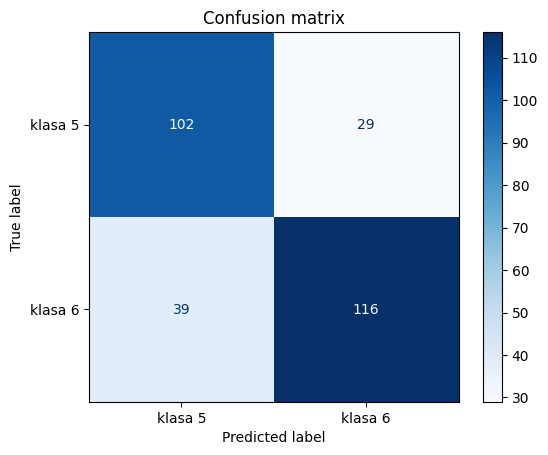

In [13]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=["klasa 5","klasa 6"]).plot(cmap="Blues")
plt.title("Confusion matrix")
plt.show()

In [14]:
## 3. Interpretowalność przez współczynniki
coefs = pd.Series(model.named_steps["clf"].coef_[0], index=numeric_features).sort_values(key=np.abs, ascending=False)
coefs.head(10)

alcohol                 0.751336
volatile acidity       -0.445412
total sulfur dioxide   -0.419253
sulphates               0.394473
density                -0.201786
chlorides              -0.168627
pH                      0.156843
citric acid             0.115184
fixed acidity           0.098876
residual sugar          0.020879
dtype: float64

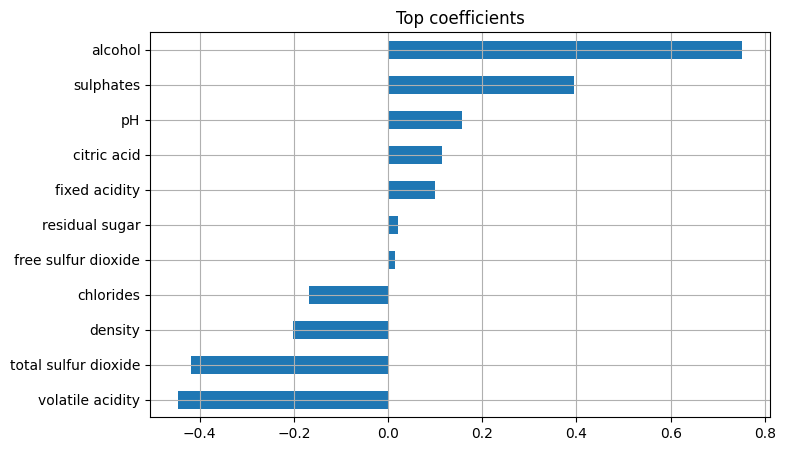

In [24]:
coefs.head(10)
coefs.head(12).sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Top coefficients")
plt.grid()
plt.show()

In [16]:
df_fair = X_test.copy()
df_fair["target"] = y_test
df_fair["group"] = (df_fair["pH"] >= df_fair["pH"].median()).astype(int)
df_fair["prediction"] = pred
df_fair["proba"] = proba
base_dataset = BinaryLabelDataset(df=df_fair, label_names=["target"], protected_attribute_names=["group"], favorable_label=6, unfavorable_label=5)
pred_df = df_fair.copy()
pred_df["target"] = df_fair["prediction"]
pred_dataset = BinaryLabelDataset(df=pred_df, label_names=["target"], protected_attribute_names=["group"], favorable_label=6, unfavorable_label=5)
metric = ClassificationMetric(base_dataset, pred_dataset, unprivileged_groups=[{"group": 0}], privileged_groups=[{"group": 1}])
fair_metrics = {
    "demographic_parity_diff": metric.mean_difference(),
    "average_odds_diff": metric.average_odds_difference(),
    "statistical_parity_diff": metric.statistical_parity_difference(),
}
fair_metrics

{'demographic_parity_diff': np.float64(0.007593200411502465),
 'average_odds_diff': np.float64(-0.03739203489203487),
 'statistical_parity_diff': np.float64(0.007593200411502465)}

In [17]:
feature = "alcohol"
ks = stats.ks_2samp(X_train[feature], X_test[feature])
print(ks)

KstestResult(statistic=np.float64(0.03900416969261777), pvalue=np.float64(0.8838767761606764), statistic_location=np.float64(10.3), statistic_sign=np.int8(-1))


In [18]:
report = pd.DataFrame({
    "metric": ["accuracy", "ks_stat", "ks_pvalue"],
    "value": [accuracy_score(y_test, pred), ks.statistic, ks.pvalue],
})
report

,metric,value
0,accuracy,0.762238
1,ks_stat,0.039004
2,ks_pvalue,0.883877


In [19]:
shifts = pd.DataFrame({
    "alcohol_mult": [1.00, 1.03, 1.06, 1.10],
    "pH_shift": [0.00, 0.05, 0.10, 0.15],
})

results = []

for _, row in shifts.iterrows():

    # kopia danych testowych
    X_shift = X_test.copy()

    # symulacja driftu
    X_shift["alcohol"] *= row["alcohol_mult"]
    X_shift["pH"] += row["pH_shift"]

    # predykcje na nowych danych
    pred_shift = model.predict(X_shift)

    # porównanie rozkładów (train vs shifted)
    ks_shift = stats.ks_2samp(
        X_train["alcohol"],
        X_shift["alcohol"]
    )

    # accuracy po drift
    acc = accuracy_score(y_test, pred_shift)

    results.append({
        "alcohol_mult": row["alcohol_mult"],
        "pH_shift": row["pH_shift"],
        "accuracy": acc,
        "ks_stat": ks_shift.statistic,
        "ks_pvalue": ks_shift.pvalue,
    })

results_df = pd.DataFrame(results)

results_df

,alcohol_mult,pH_shift,accuracy,ks_stat,ks_pvalue
0,1.00,0.00,0.762238,0.039004,8.838768e-01
1,1.03,0.05,0.741259,0.171675,5.529511e-06
2,1.06,0.10,0.751748,0.294196,7.367945e-17
3,1.10,0.15,0.706294,0.451628,5.125047e-40


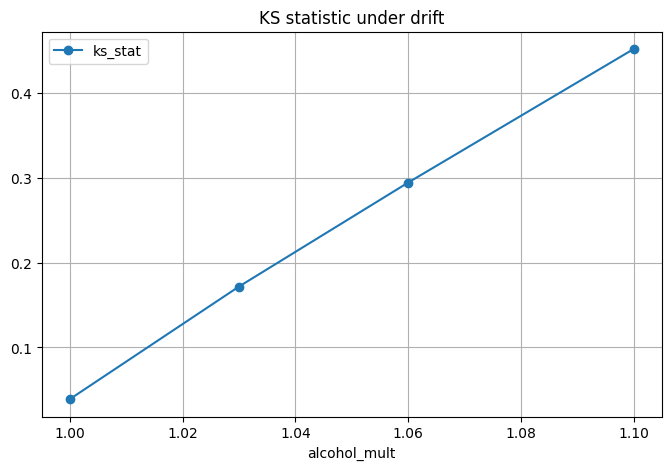

In [23]:
results_df.plot(
    x="alcohol_mult",
    y="ks_stat",
    marker="o",
    figsize=(8,5),
    title="KS statistic under drift"
)
plt.grid()
plt.show()

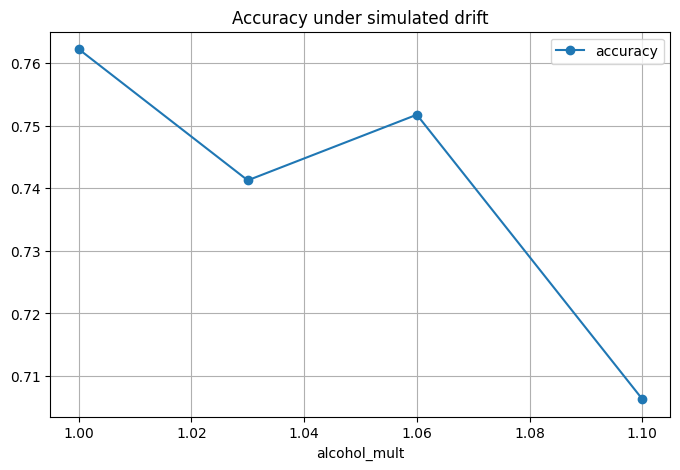

In [22]:
results_df.plot(
    x="alcohol_mult",
    y="accuracy",
    marker="o",
    figsize=(8,5),
    title="Accuracy under simulated drift"
)
plt.grid()
plt.show()